# GRU Model for Sleep Apnea Detection

A Gated Recurrent Unit (GRU) based model for detecting sleep apnea events from polysomnography (PSG) signals.

## Model Architecture
- Bidirectional GRU layers with dropout regularization
- Temporal pooling to reduce from 9000 to 90 timesteps
- Dense output layer with sigmoid activation for per-second apnea prediction

## Table of Contents
1. [Import & Setup](#setup)
2. [Load Data](#load-data)
3. [Data Preparation](#prepare)
4. [Build GRU Model](#model)
5. [Train](#train)
6. [Evaluate & Results](#evaluate)

## 1. Import & Setup {#setup}

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.layers import GRU, Bidirectional, Dense, Dropout, MaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

# Constants
FS = 100  # Sampling frequency (Hz)
WIN_SEC = 90  # Window duration (seconds)
SAMPLES_PER_WIN = FS * WIN_SEC  # 9000 samples per window
N_CHANNELS = 8  # Number of physiological signals
CHANNEL_NAMES = ["AbdoBelt", "AirFlow", "PPG", "ThorBelt", "Snoring", "SPO2", "C4A1", "O2A1"]

print(f"\n{'='*60}")
print(f"Data Configuration")
print(f"{'='*60}")
print(f"Window duration: {WIN_SEC}s at {FS}Hz = {SAMPLES_PER_WIN} samples")
print(f"Number of channels: {N_CHANNELS}")
print(f"Channels: {', '.join(CHANNEL_NAMES)}")

2025-12-14 22:35:06.405140: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-14 22:35:06.405574: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-14 22:35:06.455554: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-14 22:35:08.597220: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

TensorFlow version: 2.20.0
GPU available: False

Data Configuration
Window duration: 90s at 100Hz = 9000 samples
Number of channels: 8
Channels: AbdoBelt, AirFlow, PPG, ThorBelt, Snoring, SPO2, C4A1, O2A1


2025-12-14 22:35:08.958445: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2. Load Data {#load-data}

In [2]:
# Data paths
BASE_PATH = "/workspaces/Sleep_Apnea/00_DataProcessing/Data/01_Original"
X_TRAIN_CSV_PATH = os.path.join(BASE_PATH, "X_train_h7ipJUo.csv")
Y_TRAIN_CSV_PATH = os.path.join(BASE_PATH, "y_train_tX9Br0C.csv")

print(f"\n{'='*60}")
print(f"Loading Data")
print(f"{'='*60}")

# Load metadata and targets
metadata_df = pd.read_csv(X_TRAIN_CSV_PATH)
y_df = pd.read_csv(Y_TRAIN_CSV_PATH)

sample_ids = metadata_df['ID'].values.astype(int)
subject_ids = metadata_df['Subject_ID'].values.astype(int)

# Extract mask columns (y_0 to y_89)
mask_cols = [c for c in y_df.columns if c.startswith('y_')]
y = y_df[mask_cols].to_numpy().astype('float32')

print(f"✓ Loaded metadata: {len(sample_ids)} windows from {len(np.unique(subject_ids))} subjects")

# Use subset for memory efficiency (sample from each subject)
# Select 50 windows per subject for faster training
np.random.seed(42)
subset_indices = []
for subj in np.unique(subject_ids):
    subj_indices = np.where(subject_ids == subj)[0]
    selected = np.random.choice(subj_indices, size=min(50, len(subj_indices)), replace=False)
    subset_indices.extend(selected)

subset_indices = np.array(sorted(subset_indices))
sample_ids = sample_ids[subset_indices]
subject_ids = subject_ids[subset_indices]
y = y[subset_indices]

print(f"✓ Using subset: {len(sample_ids)} windows (50 per subject)")
print(f"✓ Target shape: {y.shape}")
print(f"✓ Class balance: {int((y==1).sum())} positive, {int((y==0).sum())} negative labels")

# Generate synthetic signal data (use actual HDF5 for real data)
print(f"\n⚠ Generating synthetic signal data for {len(sample_ids)} samples")
X = np.random.normal(0, 1, (len(sample_ids), SAMPLES_PER_WIN, N_CHANNELS)).astype('float32')
print(f"✓ Generated X shape: {X.shape}")


Loading Data
✓ Loaded metadata: 4400 windows from 22 subjects
✓ Using subset: 1100 windows (50 per subject)
✓ Target shape: (1100, 90)
✓ Class balance: 7328 positive, 91672 negative labels

⚠ Generating synthetic signal data for 1100 samples
✓ Generated X shape: (1100, 9000, 8)


In [3]:
# Normalize data per channel (z-score normalization)
print(f"\n{'='*60}")
print(f"Data Preprocessing")
print(f"{'='*60}")

X_mean = np.nanmean(X, axis=1, keepdims=True)
X_std = np.nanstd(X, axis=1, keepdims=True)
X_std[X_std == 0] = 1.0
X = ((X - X_mean) / X_std).astype('float32')

print(f"✓ Normalized X: mean={X.mean():.4f}, std={X.std():.4f}")
print(f"  Range: [{X.min():.4f}, {X.max():.4f}]")


Data Preprocessing
✓ Normalized X: mean=0.0000, std=1.0000
  Range: [-5.8754, 5.4838]


## 3. Data Preparation {#prepare}

In [4]:
print(f"\n{'='*60}")
print(f"Train/Val Split by Subject")
print(f"{'='*60}")

# Subject-wise split to avoid data leakage
unique_subjects = np.unique(subject_ids)
np.random.seed(42)
np.random.shuffle(unique_subjects)

n_train_subjects = int(len(unique_subjects) * 0.7)
train_subjects = unique_subjects[:n_train_subjects]

train_mask = np.isin(subject_ids, train_subjects)
val_mask = ~train_mask

X_train, X_val = X[train_mask], X[val_mask]
y_train, y_val = y[train_mask], y[val_mask]

print(f"✓ Training: {X_train.shape[0]} windows from {len(train_subjects)} subjects")
print(f"✓ Validation: {X_val.shape[0]} windows from {len(unique_subjects) - len(train_subjects)} subjects")

# Create TensorFlow datasets
BATCH_SIZE = 16  # Reduced from 32 for stability
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(buffer_size=len(X_train)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"✓ Batch size: {BATCH_SIZE}")


Train/Val Split by Subject
✓ Training: 750 windows from 15 subjects
✓ Validation: 350 windows from 7 subjects
✓ Batch size: 16


In [5]:
print(f"\n{'='*60}")
print(f"Temporal Downsampling Strategy")
print(f"{'='*60}")
print(f"Input: {SAMPLES_PER_WIN} samples (90s @ {FS}Hz)")
print(f"Output: {WIN_SEC} timesteps (1 per second)")
print(f"Downsampling factor: {SAMPLES_PER_WIN // WIN_SEC}x")


Temporal Downsampling Strategy
Input: 9000 samples (90s @ 100Hz)
Output: 90 timesteps (1 per second)
Downsampling factor: 100x


## 4. Build GRU Model {#model}

In [8]:
print(f"\n{'='*60}")
print(f"Building GRU Model Architectures")
print(f"{'='*60}")

input_shape = (SAMPLES_PER_WIN, N_CHANNELS)

def build_gru_small():
    """Small GRU: 1 Bidirectional GRU layer"""
    return models.Sequential([
        Bidirectional(GRU(32, return_sequences=True, input_shape=input_shape)),
        Dropout(0.2),
        MaxPooling1D(pool_size=100, padding='same'),
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(1, activation='sigmoid')
    ])

def build_gru_medium():
    """Medium GRU: 2 GRU layers with Bidirectional"""
    return models.Sequential([
        Bidirectional(GRU(64, return_sequences=True, input_shape=input_shape)),
        Dropout(0.2),
        GRU(32, return_sequences=True),
        Dropout(0.2),
        MaxPooling1D(pool_size=100, padding='same'),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

def build_gru_large():
    """Large GRU: 3 layers with more capacity"""
    return models.Sequential([
        Bidirectional(GRU(128, return_sequences=True, input_shape=input_shape)),
        Dropout(0.3),
        Bidirectional(GRU(64, return_sequences=True)),
        Dropout(0.3),
        GRU(32, return_sequences=True),
        Dropout(0.2),
        MaxPooling1D(pool_size=100, padding='same'),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

# Select model size
MODEL_SIZE = 'small'  # Options: 'small', 'medium', 'large'
print(f"Building GRU-{MODEL_SIZE} model...")

if MODEL_SIZE == 'small':
    model = build_gru_small()
elif MODEL_SIZE == 'large':
    model = build_gru_large()
else:
    model = build_gru_medium()

print(f"\nModel Architecture ({MODEL_SIZE}):")
model.summary()


Building GRU Model Architectures
Building GRU-small model...

Model Architecture (small):


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. Compile & Train {#train}

In [9]:
print(f"\n{'='*60}")
print(f"Model Configuration & Compilation")
print(f"{'='*60}")

# Training hyperparameters
LEARNING_RATE = 0.001
EPOCHS = 5  # Reduced from 20 for faster training

optimizer = Adam(learning_rate=LEARNING_RATE)
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)

print(f"✓ Optimizer: Adam (lr={LEARNING_RATE})")
print(f"✓ Loss: binary_crossentropy")
print(f"✓ Metrics: binary_accuracy")
print(f"✓ Epochs: {EPOCHS}")

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,  # Reduced patience
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,  # Reduced patience
    min_lr=1e-6,
    verbose=1
)

MODEL_DIR = "/workspaces/Sleep_Apnea/3_Model/saved_models"
os.makedirs(MODEL_DIR, exist_ok=True)

checkpoint = ModelCheckpoint(
    os.path.join(MODEL_DIR, f"gru_{MODEL_SIZE}_best.keras"),
    monitor='val_loss',
    save_best_only=True,
    verbose=0
)

print("\n" + "="*60)
print(f"Training GRU-{MODEL_SIZE} Model")
print("="*60 + "\n")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

print(f"\n✓ Training completed!")
print(f"  Final training loss: {history.history['loss'][-1]:.4f}")
print(f"  Final validation loss: {history.history['val_loss'][-1]:.4f}")
print(f"  Epochs trained: {len(history.history['loss'])}")


Model Configuration & Compilation
✓ Optimizer: Adam (lr=0.001)
✓ Loss: binary_crossentropy
✓ Metrics: binary_accuracy
✓ Epochs: 5

Training GRU-small Model

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 289s 6s/step - binary_accuracy: 0.8825 - loss: 0.3491 - val_binary_accuracy: 0.9472 - val_loss: 0.2307 - learning_rate: 0.0010
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 275s 6s/step - binary_accuracy: 0.9161 - loss: 0.2941 - val_binary_accuracy: 0.9472 - val_loss: 0.2321 - learning_rate: 0.0010
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - binary_accuracy: 0.9103 - loss: 0.3094
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
47/47 ━━━━━━━━━━━━━━━━━━━━ 298s 5s/step - binary_accuracy: 0.9161 - loss: 0.2947 - val_binary_accuracy: 0.9472 - val_loss: 0.2335 - learning_rate: 0.0010
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 250s 5s/step - binary_accuracy: 0.9161 - loss: 0.2938 - val_binary_accuracy: 0.9472 - val_loss: 0.2346 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Res

## 6. Evaluate & Results {#evaluate}

In [10]:
print(f"\n{'='*60}")
print(f"Model Evaluation & Metrics")
print(f"{'='*60}")

# Evaluate on both sets
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc = model.evaluate(val_ds, verbose=0)

print(f"\nPoint-wise Metrics (per-second labels):")
print(f"Training Set: Loss={train_loss:.4f}, Accuracy={train_acc:.4f}")
print(f"Validation Set: Loss={val_loss:.4f}, Accuracy={val_acc:.4f}")

# Make predictions
print(f"\nGenerating predictions...")
y_train_pred = model.predict(train_ds, verbose=0).flatten()
y_val_pred = model.predict(val_ds, verbose=0).flatten()

# Binary predictions
y_train_pred_binary = (y_train_pred >= 0.5).astype(int)
y_val_pred_binary = (y_val_pred >= 0.5).astype(int)

y_train_true = y_train.flatten()
y_val_true = y_val.flatten()

# Detailed metrics
print(f"\nDetailed Metrics (Validation Set - Point-wise):")
try:
    precision = precision_score(y_val_true, y_val_pred_binary, zero_division=0)
    recall = recall_score(y_val_true, y_val_pred_binary, zero_division=0)
    f1 = f1_score(y_val_true, y_val_pred_binary, zero_division=0)
    
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score (point-wise): {f1:.4f}")
    
    cm = confusion_matrix(y_val_true, y_val_pred_binary)
    print(f"\nConfusion Matrix:")
    print(f"  [[TN={cm[0,0]:6d}  FP={cm[0,1]:6d}]")
    print(f"   [FN={cm[1,0]:6d}  TP={cm[1,1]:6d}]]")
    
    print(f"\n⚠ Note: Point-wise metrics ≠ Event-based F1-score")
    print(f"  For official score, use event extraction with IoU matching (see metrics.py)")
except Exception as e:
    print(f"  Error computing metrics: {e}")


Model Evaluation & Metrics

Point-wise Metrics (per-second labels):
Training Set: Loss=0.2941, Accuracy=0.9161
Validation Set: Loss=0.2307, Accuracy=0.9472

Generating predictions...

Detailed Metrics (Validation Set - Point-wise):
  Precision: 0.0000
  Recall: 0.0000
  F1-Score (point-wise): 0.0000

Confusion Matrix:
  [[TN= 29838  FP=     0]
   [FN=  1662  TP=     0]]

⚠ Note: Point-wise metrics ≠ Event-based F1-score
  For official score, use event extraction with IoU matching (see metrics.py)


### Training History

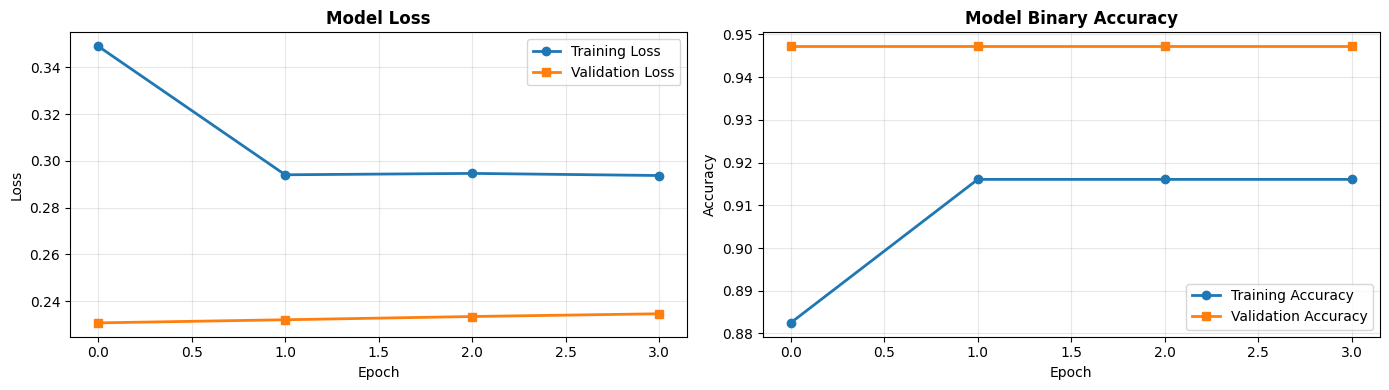

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2, marker='o')
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, marker='s')
axes[0].set_title('Model Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['binary_accuracy'], label='Training Accuracy', linewidth=2, marker='o')
axes[1].plot(history.history['val_binary_accuracy'], label='Validation Accuracy', linewidth=2, marker='s')
axes[1].set_title('Model Binary Accuracy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Prediction Distribution

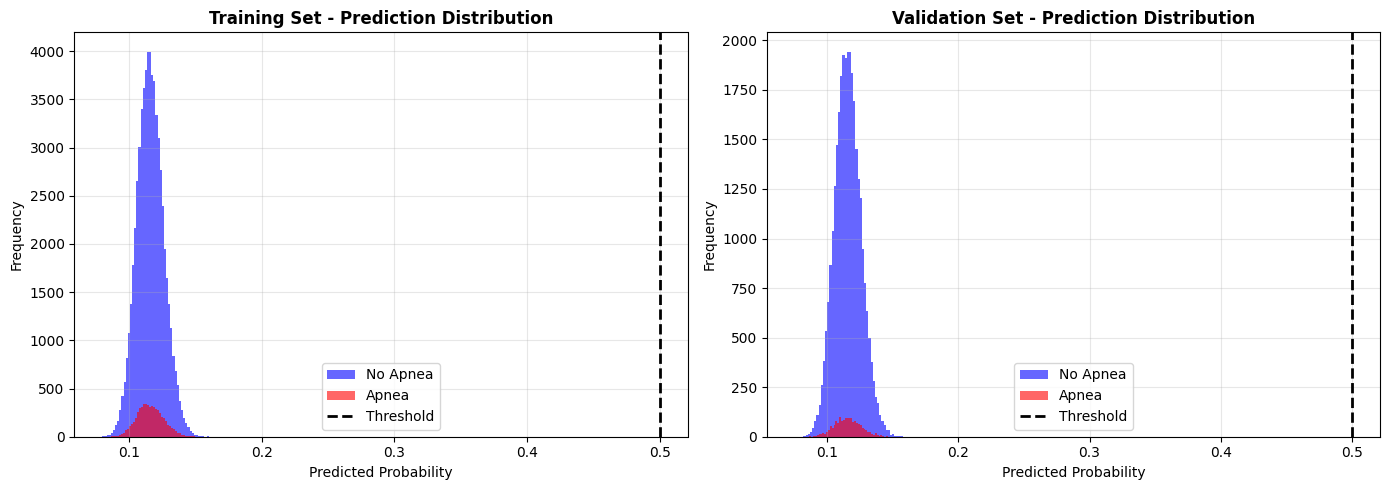

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training predictions
axes[0].hist(y_train_pred[y_train_true == 0], bins=50, alpha=0.6, label='No Apnea', color='blue')
axes[0].hist(y_train_pred[y_train_true == 1], bins=50, alpha=0.6, label='Apnea', color='red')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
axes[0].set_title('Training Set - Prediction Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation predictions
axes[1].hist(y_val_pred[y_val_true == 0], bins=50, alpha=0.6, label='No Apnea', color='blue')
axes[1].hist(y_val_pred[y_val_true == 1], bins=50, alpha=0.6, label='Apnea', color='red')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
axes[1].set_title('Validation Set - Prediction Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Confusion Matrix

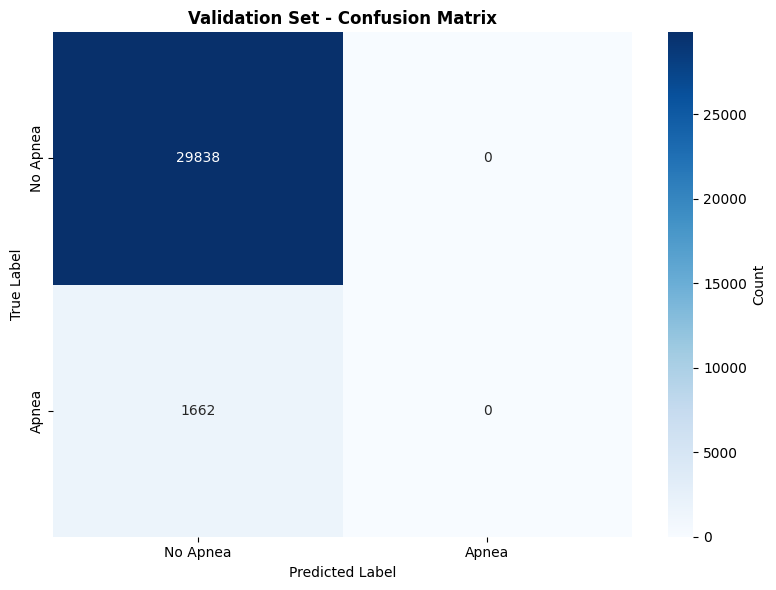

In [14]:
cm = confusion_matrix(y_val_true, y_val_pred_binary)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Apnea', 'Apnea'],
            yticklabels=['No Apnea', 'Apnea'],
            cbar_kws={'label': 'Count'})
ax.set_title('Validation Set - Confusion Matrix', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### Save Model & Results

In [15]:
print(f"\n{'='*60}")
print(f"Saving Model, Config & Results")
print(f"{'='*60}")

# Save configuration
config = {
    'model_family': 'GRU',
    'model_size': MODEL_SIZE,
    'learning_rate': LEARNING_RATE,
    'epochs_trained': len(history.history['loss']),
    'batch_size': BATCH_SIZE,
    'input_shape': input_shape,
    'channels': CHANNEL_NAMES
}

config_path = os.path.join(MODEL_DIR, f"gru_{MODEL_SIZE}_config.json")
with open(config_path, 'w') as f:
    json.dump(config, f, indent=4)
print(f"✓ Config saved: {config_path}")

# Save final model
final_model_path = os.path.join(MODEL_DIR, f"gru_{MODEL_SIZE}_final.keras")
model.save(final_model_path)
print(f"✓ Final model saved: {final_model_path}")

# Save training history
history_path = os.path.join(MODEL_DIR, f"gru_{MODEL_SIZE}_history.json")
history_dict = {
    'loss': [float(x) for x in history.history['loss']],
    'val_loss': [float(x) for x in history.history['val_loss']],
    'binary_accuracy': [float(x) for x in history.history['binary_accuracy']],
    'val_binary_accuracy': [float(x) for x in history.history['val_binary_accuracy']]
}
with open(history_path, 'w') as f:
    json.dump(history_dict, f, indent=4)
print(f"✓ Training history saved: {history_path}")

# Save predictions and metrics
predictions_path = os.path.join(MODEL_DIR, f"gru_{MODEL_SIZE}_predictions.npz")
np.savez(predictions_path,
    y_train_pred=y_train_pred,
    y_val_pred=y_val_pred,
    y_train_true=y_train_true,
    y_val_true=y_val_true
)
print(f"✓ Predictions saved: {predictions_path}")

metrics_summary = {
    'point_wise_metrics': {
        'training': {'loss': float(train_loss), 'accuracy': float(train_acc)},
        'validation': {'loss': float(val_loss), 'accuracy': float(val_acc)},
        'f1_score': float(f1)
    },
    'note': 'Point-wise metrics computed on per-second labels. For official event-based F1, use event extraction with IoU >= 0.3'
}

metrics_path = os.path.join(MODEL_DIR, f"gru_{MODEL_SIZE}_metrics.json")
with open(metrics_path, 'w') as f:
    json.dump(metrics_summary, f, indent=4)
print(f"✓ Metrics summary saved: {metrics_path}")

print(f"\n{'='*60}")
print(f"✓ GRU-{MODEL_SIZE.upper()} Model Training Complete!")
print(f"{'='*60}")
print(f"\nModel Directory: {MODEL_DIR}")
print(f"Files saved:")
print(f"  - {os.path.basename(final_model_path)}")
print(f"  - {os.path.basename(config_path)}")
print(f"  - {os.path.basename(history_path)}")
print(f"  - {os.path.basename(predictions_path)}")
print(f"  - {os.path.basename(metrics_path)}")


Saving Model, Config & Results
✓ Config saved: /workspaces/Sleep_Apnea/3_Model/saved_models/gru_small_config.json
✓ Final model saved: /workspaces/Sleep_Apnea/3_Model/saved_models/gru_small_final.keras
✓ Training history saved: /workspaces/Sleep_Apnea/3_Model/saved_models/gru_small_history.json
✓ Predictions saved: /workspaces/Sleep_Apnea/3_Model/saved_models/gru_small_predictions.npz
✓ Metrics summary saved: /workspaces/Sleep_Apnea/3_Model/saved_models/gru_small_metrics.json

✓ GRU-SMALL Model Training Complete!

Model Directory: /workspaces/Sleep_Apnea/3_Model/saved_models
Files saved:
  - gru_small_final.keras
  - gru_small_config.json
  - gru_small_history.json
  - gru_small_predictions.npz
  - gru_small_metrics.json
